# CI2604P — Smoker Status Prediction from Bio-Signals



## 0. Imports & Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Load Data

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()

Train shape: (15000, 24)
Test shape : (10000, 23)


,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,35.0,175.0,75.0,81.0,1.2,1.2,1.0,1.0,120.0,80.0,87.0,182.0,67.0,63.0,105.0,14.3,1.0,0.9,18.0,16.0,15.0,0.0,1.0
1,1,35.0,165.0,70.0,82.0,1.5,1.2,1.0,1.0,138.0,88.0,85.0,233.0,360.0,68.0,83.0,15.3,1.0,0.7,105.0,173.0,483.0,1.0,1.0
2,2,40.0,180.0,70.0,82.0,1.2,1.0,1.0,1.0,119.0,67.0,106.0,172.0,85.0,51.0,104.0,14.3,1.0,1.0,18.0,14.0,23.0,1.0,1.0
3,3,40.0,150.0,55.0,75.2,1.5,1.2,1.0,1.0,110.0,70.0,95.0,185.0,57.0,61.0,112.0,14.0,1.0,0.9,17.0,14.0,17.0,0.0,0.0
4,4,35.0,170.0,75.0,89.0,1.0,1.2,1.0,1.0,133.0,84.0,98.0,228.0,161.0,52.0,144.0,15.2,2.0,0.9,42.0,59.0,35.0,0.0,1.0


## 2. Exploratory Data Analysis (EDA)



In [4]:
print("Missing values (train):", train_df.isna().sum().sum())
print("Missing values (test) :", test_df.isna().sum().sum())
print("Duplicate rows (train):", train_df.duplicated().sum())
train_df.describe().T

Missing values (train): 0
Missing values (test) : 0
Duplicate rows (train): 0


,count,mean,std,min,25%,50%,75%,max
id,15000.0,7499.500000,4330.271354,0.0,3749.75,7499.5,11249.25,14999.0
age,15000.0,42.683333,10.544215,20.0,40.00,40.0,50.00,80.0
height(cm),15000.0,164.606333,8.524565,140.0,160.00,165.0,170.00,190.0
weight(kg),15000.0,64.142333,10.961786,35.0,55.00,65.0,70.00,115.0
waist(cm),15000.0,80.223093,7.882613,58.0,75.00,80.0,85.50,114.0
eyesight(left),15000.0,1.032700,0.321799,0.1,0.80,1.0,1.20,9.9
eyesight(right),15000.0,1.027887,0.304696,0.1,0.80,1.0,1.20,9.9
hearing(left),15000.0,1.005533,0.074183,1.0,1.00,1.0,1.00,2.0
hearing(right),15000.0,1.006667,0.081380,1.0,1.00,1.0,1.00,2.0
systolic,15000.0,119.217467,11.116583,86.0,110.00,119.0,128.00,170.0


### 2.1 Target Distribution


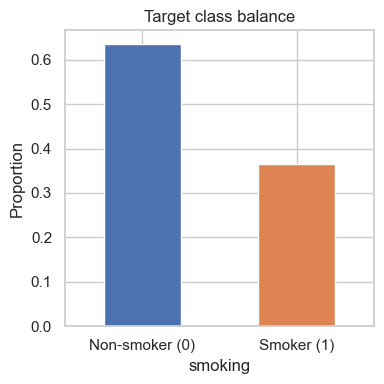

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
train_df["smoking"].value_counts(normalize=True).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#DD8452"]
)
ax.set_xticklabels(["Non-smoker (0)", "Smoker (1)"], rotation=0)
ax.set_ylabel("Proportion")
ax.set_title("Target class balance")
plt.tight_layout()
plt.show()

### 2.2 Feature Correlation with Target


In [6]:
corr_with_target = (
    train_df.drop(columns=["id"])
    .corr(numeric_only=True)["smoking"]
    .drop("smoking")
    .sort_values(key=np.abs, ascending=False)
)
corr_with_target

hemoglobin             0.502415
height(cm)             0.483875
weight(kg)             0.392845
Gtp                    0.364389
serum creatinine       0.357419
triglyceride           0.352083
waist(cm)              0.301829
HDL                   -0.293760
ALT                    0.249011
age                   -0.184286
relaxation             0.163415
eyesight(right)        0.141728
dental caries          0.134024
systolic               0.129280
eyesight(left)         0.116255
fasting blood sugar    0.113894
AST                    0.098296
LDL                   -0.054020
Cholesterol           -0.050796
hearing(right)        -0.011192
hearing(left)         -0.010004
Urine protein          0.004039
Name: smoking, dtype: float64

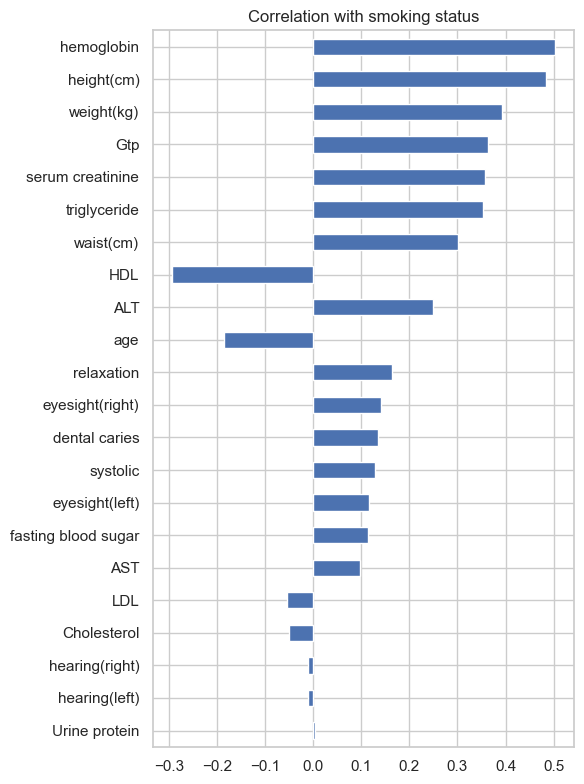

In [7]:
fig, ax = plt.subplots(figsize=(6, 8))
corr_with_target.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Correlation with smoking status")
plt.tight_layout()
plt.show()

`hemoglobin`, `Gtp`, `height(cm)`, `triglyceride`, `weight(kg)` and
`serum creatinine` show the strongest linear association — this lines up
with the domain knowledge that smoking affects hemoglobin/liver enzymes
and correlates with body-composition traits.

### 2.3 Distribution of Top Features by Class

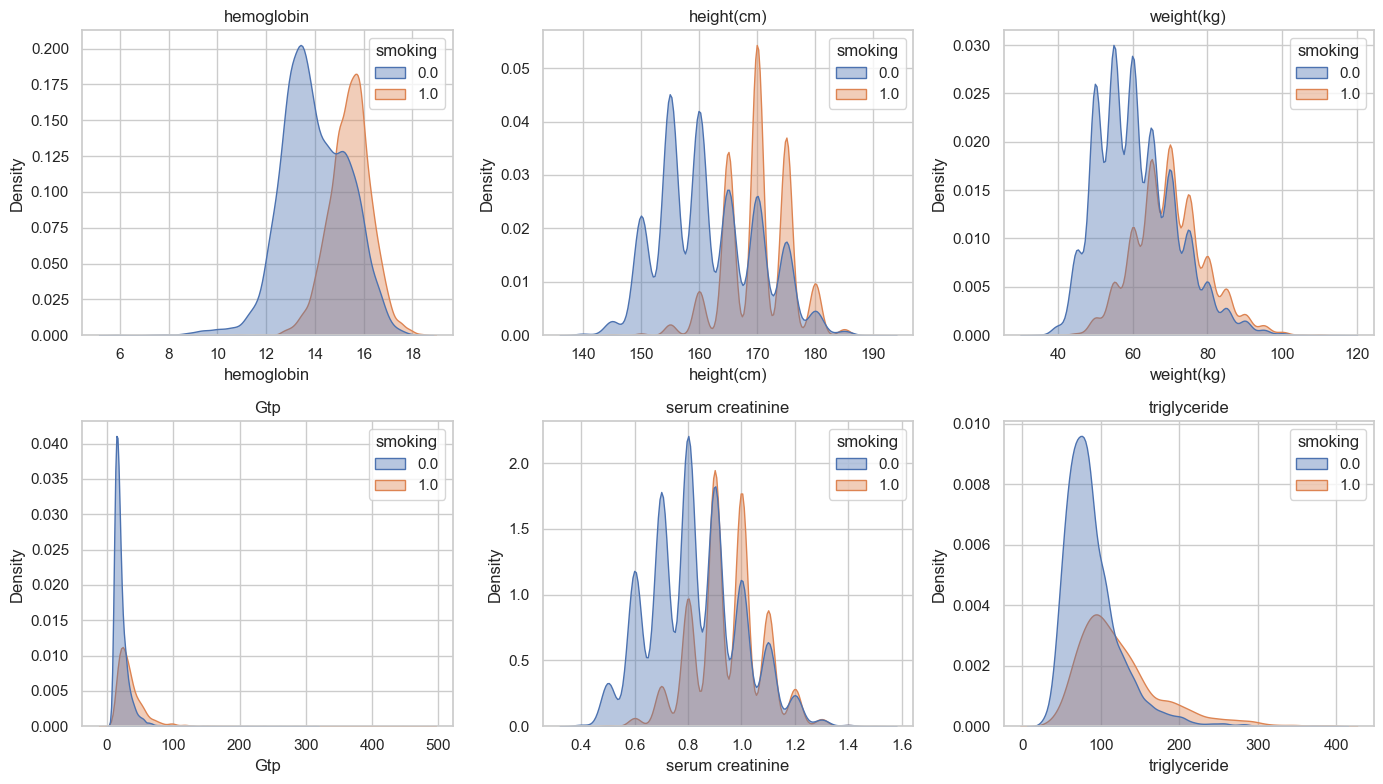

In [8]:
top_feats = corr_with_target.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for feat, ax in zip(top_feats, axes.ravel()):
    sns.kdeplot(data=train_df, x=feat, hue="smoking", fill=True, alpha=0.4, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

### 2.4 Outlier Check


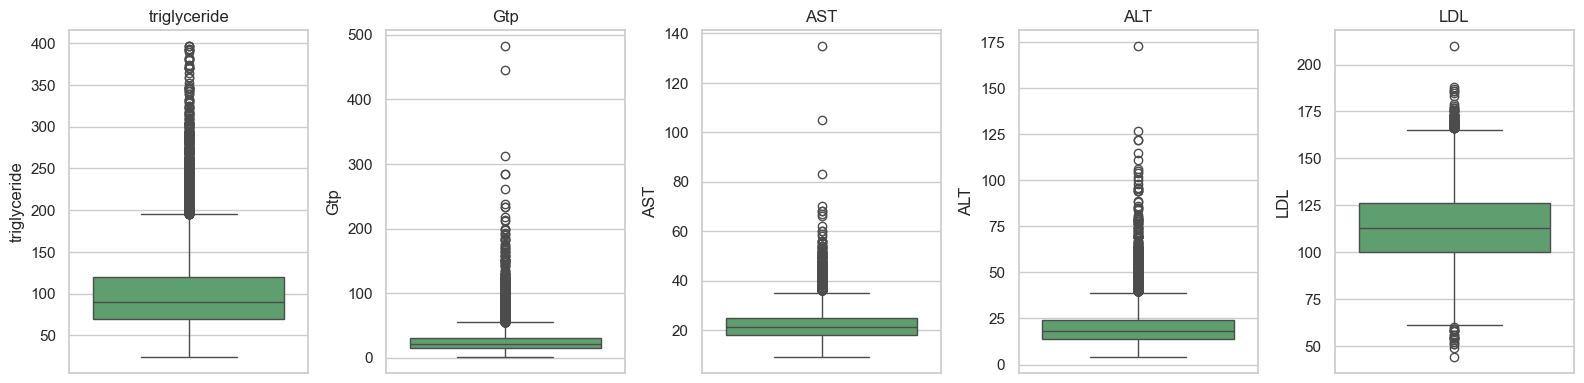

In [9]:
outlier_cols = ["triglyceride", "Gtp", "AST", "ALT", "LDL"]
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for col, ax in zip(outlier_cols, axes):
    sns.boxplot(y=train_df[col], ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Feature Engineering



In [10]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Body Mass Index — standard clinical formula
    df["BMI"] = df["weight(kg)"] / ((df["height(cm)"] / 100) ** 2)

    # Waist-to-height ratio — a known better predictor of metabolic risk than BMI alone
    df["waist_height_ratio"] = df["waist(cm)"] / df["height(cm)"]

    # Blood pressure derived measures
    df["pulse_pressure"] = df["systolic"] - df["relaxation"]
    df["mean_arterial_pressure"] = df["relaxation"] + df["pulse_pressure"] / 3

    # Average eyesight / cap the "9.9 = blind" sentinel value that this dataset
    # family is known to use, so it doesn't distort averages
    for c in ["eyesight(left)", "eyesight(right)"]:
        df[c] = df[c].clip(upper=2.5)
    df["eyesight_avg"] = (df["eyesight(left)"] + df["eyesight(right)"]) / 2

    # Hearing: combine both ears into one "any hearing loss" flag
    df["hearing_any_loss"] = (
        (df["hearing(left)"] > 1) | (df["hearing(right)"] > 1)
    ).astype(int)

    # Lipid ratios — clinically meaningful combinations of the raw lipid panel
    df["chol_hdl_ratio"] = df["Cholesterol"] / df["HDL"]
    df["ldl_hdl_ratio"] = df["LDL"] / df["HDL"]
    df["triglyceride_hdl_ratio"] = df["triglyceride"] / df["HDL"]

    # Liver enzyme ratio (AST/ALT, the "De Ritis ratio") — used clinically to
    # flag liver stress, which is influenced by smoking/alcohol
    df["ast_alt_ratio"] = df["AST"] / df["ALT"].replace(0, np.nan)
    df["ast_alt_ratio"] = df["ast_alt_ratio"].fillna(df["ast_alt_ratio"].median())

    # Log-transform heavily right-skewed lab values to tame outliers
    for c in ["triglyceride", "Gtp", "AST", "ALT", "LDL", "serum creatinine"]:
        df[f"log_{c}"] = np.log1p(df[c])

    return df


train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

new_cols = [c for c in train_fe.columns if c not in train_df.columns]
print(f"Added {len(new_cols)} engineered features:\n{new_cols}")

Added 16 engineered features:
['BMI', 'waist_height_ratio', 'pulse_pressure', 'mean_arterial_pressure', 'eyesight_avg', 'hearing_any_loss', 'chol_hdl_ratio', 'ldl_hdl_ratio', 'triglyceride_hdl_ratio', 'ast_alt_ratio', 'log_triglyceride', 'log_Gtp', 'log_AST', 'log_ALT', 'log_LDL', 'log_serum creatinine']


## 4. Preprocessing



In [11]:
FEATURE_COLS = [c for c in train_fe.columns if c not in ["id", "smoking"]]
X = train_fe[FEATURE_COLS]
y = train_fe["smoking"]
X_test = test_fe[FEATURE_COLS]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (12000, 38)  Val: (3000, 38)  Test: (10000, 38)


## 5. Model Selection & Experimentation



In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="auc",
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=400, max_depth=-1, num_leaves=31, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
        random_state=RANDOM_STATE, verbose=-1
    ),
}

results = []
for name, model in models.items():
    # Logistic Regression needs scaled features; tree models don't.
    Xc = X_train_scaled if name == "Logistic Regression" else X_train
    cv_scores = []
    for tr_idx, va_idx in cv.split(Xc, y_train):
        Xc_tr = Xc[tr_idx] if isinstance(Xc, np.ndarray) else Xc.iloc[tr_idx]
        Xc_va = Xc[va_idx] if isinstance(Xc, np.ndarray) else Xc.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model.fit(Xc_tr, y_tr)
        preds = model.predict_proba(Xc_va)[:, 1]
        cv_scores.append(roc_auc_score(y_va, preds))

    # Refit on full training split, score on held-out validation set
    Xv = X_val_scaled if name == "Logistic Regression" else X_val
    model.fit(Xc, y_train)
    val_auc = roc_auc_score(y_val, model.predict_proba(Xv)[:, 1])

    results.append({
        "model": name,
        "cv_auc_mean": np.mean(cv_scores),
        "cv_auc_std": np.std(cv_scores),
        "val_auc": val_auc,
    })
    print(f"{name:22s} | CV AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f} | Val AUC: {val_auc:.4f}")

results_df = pd.DataFrame(results).sort_values("val_auc", ascending=False)
results_df

Logistic Regression    | CV AUC: 0.8768 ± 0.0063 | Val AUC: 0.8764
Random Forest          | CV AUC: 0.8835 ± 0.0070 | Val AUC: 0.8818
XGBoost                | CV AUC: 0.8876 ± 0.0078 | Val AUC: 0.8902
LightGBM               | CV AUC: 0.8862 ± 0.0080 | Val AUC: 0.8856


,model,cv_auc_mean,cv_auc_std,val_auc
2,XGBoost,0.887594,0.007772,0.890215
3,LightGBM,0.886154,0.008007,0.885574
1,Random Forest,0.883543,0.006958,0.881813
0,Logistic Regression,0.876787,0.006340,0.876397


In [13]:
best_model_name = results_df.iloc[0]["model"]
print("Best baseline model:", best_model_name)

Best baseline model: XGBoost


## 6. Hyperparameter Tuning (LightGBM)


In [14]:
param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8, 10],
    "learning_rate": [0.01, 0.02, 0.05, 0.08],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_samples": [10, 20, 30, 50],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0, 0.1, 0.5, 1.0],
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)
lgbm_search.fit(X_train, y_train)

print("Best CV ROC AUC:", lgbm_search.best_score_)
print("Best params:")
for k, v in lgbm_search.best_params_.items():
    print(f"  {k}: {v}")

Best CV ROC AUC: 0.8892036015433475
Best params:
  subsample: 0.8
  reg_lambda: 1.0
  reg_alpha: 0.5
  num_leaves: 15
  n_estimators: 500
  min_child_samples: 50
  max_depth: 4
  learning_rate: 0.02
  colsample_bytree: 0.7


In [15]:
best_lgbm = lgbm_search.best_estimator_
val_preds = best_lgbm.predict_proba(X_val)[:, 1]
tuned_val_auc = roc_auc_score(y_val, val_preds)
print(f"Tuned LightGBM — Held-out Validation ROC AUC: {tuned_val_auc:.4f}")

Tuned LightGBM — Held-out Validation ROC AUC: 0.8899


### 6.1 Validation ROC Curve

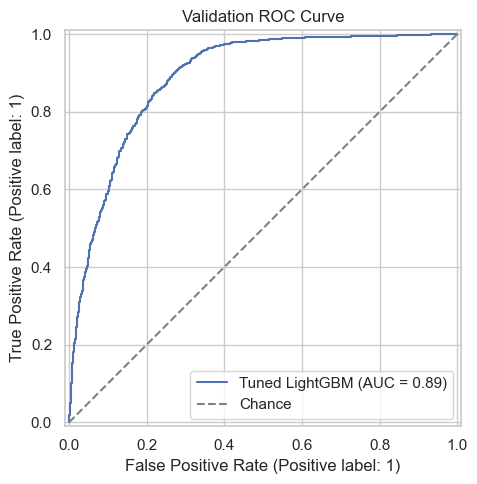

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_val, val_preds, ax=ax, name="Tuned LightGBM")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("Validation ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Feature Importance

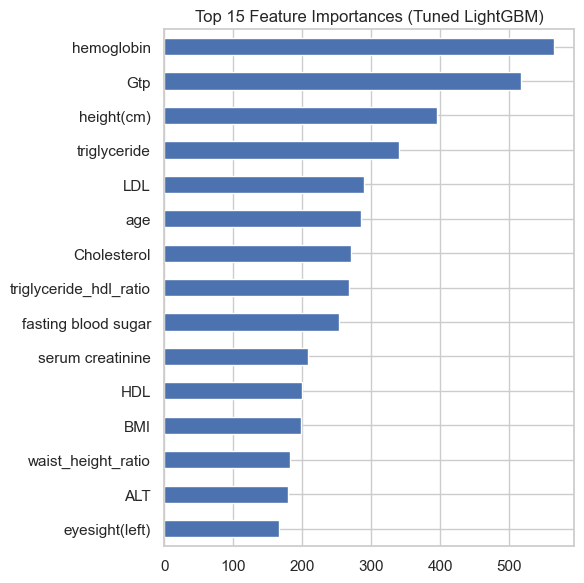

In [17]:
importances = pd.Series(best_lgbm.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(6, 6))
importances.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Top 15 Feature Importances (Tuned LightGBM)")
plt.tight_layout()
plt.show()

## 7. Final Model 


In [18]:
final_model = LGBMClassifier(
    **lgbm_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
final_model.fit(X, y)

# Sanity check: in-sample AUC should be high but this is NOT the metric we report
in_sample_auc = roc_auc_score(y, final_model.predict_proba(X)[:, 1])
print(f"In-sample ROC AUC (sanity check only): {in_sample_auc:.4f}")
print(f"(Trustworthy estimate is the held-out validation AUC above: {tuned_val_auc:.4f})")

In-sample ROC AUC (sanity check only): 0.9172
(Trustworthy estimate is the held-out validation AUC above: 0.8899)


## 8. Submission



In [19]:
test_probabilities = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "id": test_fe["id"],
    "smoking": test_probabilities
})

assert submission["smoking"].between(0, 1).all(), "Probabilities must be in [0, 1]"
assert submission.shape[0] == test_df.shape[0], "Row count must match test set"
assert submission["id"].is_unique, "id column must be unique"

submission.to_csv("submission.csv", index=False)
print("Submission file saved.")
submission.head()

Submission file saved.


,id,smoking
0,15000,0.845896
1,15001,0.608268
2,15002,0.542045
3,15003,0.739323
4,15004,0.843042
